# 11 — Positional Information

## Goal

Self-attention compares token representations based on their content.

However, language is ordered.

The sequences

> dog bites man

and

> man bites dog

contain the same tokens but have very different meanings.

This lesson studies how Transformers represent token position.

We will build the ideas progressively:

1. why content-only self-attention is insufficient,
2. learned positional embeddings,
3. sinusoidal positional encodings,
4. Rotary Position Embeddings (RoPE).

The final goal is to understand how position can be injected either
into token representations or directly into the geometry of attention.

In [1]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

## 1. Why Does Attention Need Positional Information?

Consider an input sequence represented by

$$
X \in \mathbb{R}^{T \times C}.
$$

Self-attention computes

$$
Q = XW_Q,
\qquad
K = XW_K,
\qquad
V = XW_V,
$$

followed by

$$
A
=
\operatorname{softmax}
\left(
\frac{QK^\top}{\sqrt{D}}
\right).
$$

Nothing in these projections explicitly says:

- this token is at position 0,
- this token is at position 5,
- these two tokens are three positions apart.

The attention mechanism primarily compares the content representations
of tokens.

Without additional positional information, ordinary self-attention is
permutation equivariant: permuting the input tokens permutes the outputs
in the same way.

In [2]:
def simple_self_attention(x: torch.Tensor) -> torch.Tensor:
    scores: torch.Tensor = (x @ x.transpose(-2, -1)) / math.sqrt(x.shape[-1])

    weights: torch.Tensor = torch.softmax(scores, dim=-1)

    return weights @ x


x: torch.Tensor = torch.tensor(
    [
        [1.0, 0.0],
        [0.0, 1.0],
        [1.0, 1.0],
    ]
)

print(x.shape)

output_original: torch.Tensor = simple_self_attention(x)

print(output_original)

torch.Size([3, 2])
tensor([[0.8022, 0.5989],
        [0.5989, 0.8022],
        [0.7517, 0.7517]])


In [3]:
permutation: torch.Tensor = torch.tensor([2, 0, 1])

x_permuted: torch.Tensor = x[permutation]

output_permuted: torch.Tensor = simple_self_attention(x_permuted)

expected_permuted_output: torch.Tensor = output_original[permutation]

print(
    torch.allclose(
        output_permuted,
        expected_permuted_output,
        atol=1e-6,
    )
)

True


### A Note About Causal Masking

A causal mask itself depends on sequence position.

Therefore, causal self-attention is not fully permutation equivariant
in the same way as unmasked self-attention.

However, the causal mask mainly specifies **visibility**:

> which tokens are allowed to interact?

It does not provide a rich representation of positional relationships
such as:

- absolute position,
- relative distance,
- nearby versus far-away tokens.

Positional representations therefore serve a different purpose from the
causal mask.

The causal mask answers:

> Can I attend to this token?

Positional information helps answer:

> Where is this token relative to me?

## 2. Learned Positional Embeddings

One simple way to represent position is to learn a separate embedding
for **every possible sequence index**.

Suppose the maximum context length is

$$
T_{\max}.
$$

A positional embedding table has shape

$$
P
\in
\mathbb{R}^{T_{\max}\times C}.
$$

For position $t$, we select

$$
P_t \in \mathbb{R}^{C}.
$$

The model input becomes

$$
X_t
=
E_{\text{token}}(token_t)
+
P_t.
$$

Token identity and token position therefore occupy the same model
dimension and are combined by element-wise addition.

why addition?

because the add op doesn't change the dim of orignal tensor. 

In [4]:
vocab_size: int = 100
max_sequence_length: int = 16
embedding_dim: int = 8

token_embedding = nn.Embedding(
    vocab_size,
    embedding_dim,
)

position_embedding = nn.Embedding(
    max_sequence_length,
    embedding_dim,
)

token_ids: torch.Tensor = torch.tensor(
    [
        [5, 8, 2, 9],
        [4, 1, 7, 3],
    ]
)

print(token_ids.shape)

torch.Size([2, 4])


In [5]:
sequence_length: int = token_ids.shape[1]

position_ids: torch.Tensor = torch.arange(sequence_length)

print(position_ids)
print(position_ids.shape)


token_vectors: torch.Tensor = token_embedding(token_ids)

position_vectors: torch.Tensor = position_embedding(position_ids)

print(
    "token vectors:",
    token_vectors.shape,
)

print(
    "position vectors:",
    position_vectors.shape,
)

x: torch.Tensor = token_vectors + position_vectors

print(x.shape)

tensor([0, 1, 2, 3])
torch.Size([4])
token vectors: torch.Size([2, 4, 8])
position vectors: torch.Size([4, 8])
torch.Size([2, 4, 8])


In [6]:
# same token in different pos showing different representations.

same_token_ids: torch.Tensor = torch.tensor([[5, 5, 5]])

positions: torch.Tensor = torch.arange(3)

token_vectors: torch.Tensor = token_embedding(same_token_ids)

position_vectors: torch.Tensor = position_embedding(positions)

combined: torch.Tensor = token_vectors + position_vectors

print(combined)

tensor([[[-2.5179, -1.5273,  0.1022,  0.7491,  1.3653,  0.4836,  2.1401,
          -0.4247],
         [-2.1721, -0.7570,  1.3300, -0.0889,  1.5402,  2.9346,  2.6426,
           1.6864],
         [-1.1915,  0.6710,  3.4529,  0.9841,  2.8686,  2.2510,  3.1453,
           0.2873]]], grad_fn=<AddBackward0>)


### Limitation: Fixed Learned Positions

A learned positional embedding table contains a finite number of rows.

If

$$
P
\in
\mathbb{R}^{T_{\max}\times C},
$$

then the model only has learned vectors for positions

$$
0,\ldots,T_{\max}-1.
$$

Extending the context beyond this range requires additional positional
parameters or another strategy.

This limitation motivates positional representations that are generated
mathematically rather than stored as an independent learned vector for
every position.

## 3. Sinusoidal Positional Encoding

Learned positional embeddings assign an independent learned vector to
every position.

Sinusoidal positional encoding takes a different approach:

> generate positional vectors directly from deterministic mathematical
> functions.

For position $p$ and model dimension $C$, the original Transformer
formulation defines

$$
PE(p, 2i)
=
\sin
\left(
\frac{p}
{10000^{2i/C}}
\right),
$$

and

$$
PE(p, 2i+1)
=
\cos
\left(
\frac{p}
{10000^{2i/C}}
\right).
$$

Each pair of feature dimensions therefore uses the same frequency:

$$
(\sin(p\omega_i), \cos(p\omega_i)).
$$

Different dimension pairs use different frequencies.

In [7]:
embedding_dim: int = 8

pair_indices: torch.Tensor = torch.arange(
    0,
    embedding_dim,
    2,
)

frequencies: torch.Tensor = torch.pow(
    10000.0,
    -pair_indices / embedding_dim,
)

print("pair indices:", pair_indices)
print("frequencies:", frequencies)

pair indices: tensor([0, 2, 4, 6])
frequencies: tensor([1.0000, 0.1000, 0.0100, 0.0010])


In [8]:
max_sequence_length: int = 16

positions: torch.Tensor = torch.arange(
    max_sequence_length,
    dtype=torch.float32,
)

print(positions.shape)

torch.Size([16])


In [9]:
angles: torch.Tensor = positions.unsqueeze(1) * frequencies.unsqueeze(0)

print(angles.shape)

torch.Size([16, 4])


In [10]:
sin_values: torch.Tensor = torch.sin(angles)

cos_values: torch.Tensor = torch.cos(angles)

In [11]:
# all in one
def sinusoidal_positional_encoding(
    sequence_length: int, embedding_dim: int
) -> torch.Tensor:
    if embedding_dim % 2 != 0:
        raise ValueError(
            "embedding_dim must be evenfor this educational implementaton"
        )
    positions: torch.Tensor = torch.arange(sequence_length, dtype=torch.float32)

    dimention_indices: torch.Tensor = torch.arange(
        0, embedding_dim, 2, dtype=torch.float32
    )

    frequencies: torch.Tensor = torch.pow(
        10000.0, -dimention_indices / embedding_dim
    )

    angles: torch.Tensor = positions.unsqueeze(1) * frequencies.unsqueeze(0)

    encoding: torch.Tensor = torch.zeros(sequence_length, embedding_dim)

    encoding[:, 0::2] = torch.sin(angles)
    encoding[:, 1::2] = torch.cos(angles)

    return encoding


encoding: torch.Tensor = sinusoidal_positional_encoding(
    sequence_length=16,
    embedding_dim=8,
)

print(encoding.shape)
print(encoding[:4])

torch.Size([16, 8])
tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00],
        [ 1.4112e-01, -9.8999e-01,  2.9552e-01,  9.5534e-01,  2.9995e-02,
          9.9955e-01,  3.0000e-03,  1.0000e+00]])


In [12]:
token_vectors: torch.Tensor = torch.randn(
    2,
    16,
    8,
)

position_vectors: torch.Tensor = sinusoidal_positional_encoding(
    sequence_length=16,
    embedding_dim=8,
)

x: torch.Tensor = token_vectors + position_vectors

print(x.shape)

torch.Size([2, 16, 8])


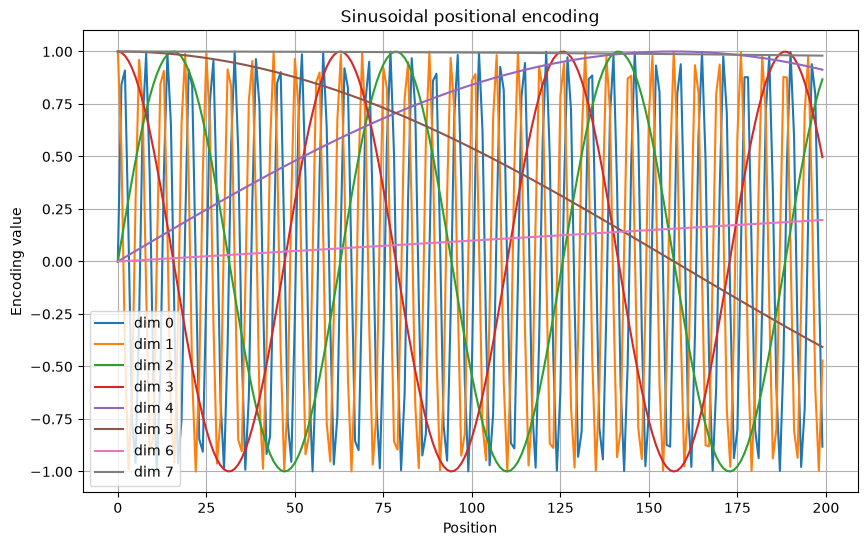

In [13]:
encoding: torch.Tensor = sinusoidal_positional_encoding(
    sequence_length=200,
    embedding_dim=8,
)

positions: torch.Tensor = torch.arange(200)

plt.figure(figsize=(10, 6))

for dimension in range(8):
    plt.plot(
        positions.numpy(),
        encoding[:, dimension].numpy(),
        label=f"dim {dimension}",
    )

plt.xlabel("Position")
plt.ylabel("Encoding value")
plt.title("Sinusoidal positional encoding")
plt.legend()
plt.grid(True)

plt.show()

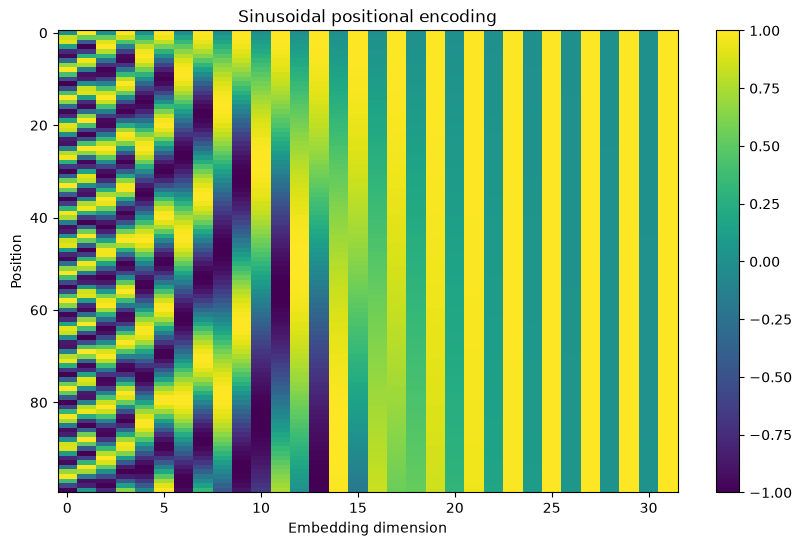

In [14]:
encoding: torch.Tensor = sinusoidal_positional_encoding(
    sequence_length=100,
    embedding_dim=32,
)

plt.figure(figsize=(10, 6))

plt.imshow(
    encoding.numpy(),
    aspect="auto",
)

plt.xlabel("Embedding dimension")
plt.ylabel("Position")
plt.title("Sinusoidal positional encoding")

plt.colorbar()

plt.show()

### Relative Position Structure

For one sinusoidal frequency,

$$
PE(p)
=
\begin{bmatrix}
\sin(p\omega) \\
\cos(p\omega)
\end{bmatrix}.
$$

Moving by an offset $k$ gives

$$
PE(p+k)
=
R(k)PE(p),
$$

where

$$
R(k)
=
\begin{bmatrix}
\cos(k\omega) & \sin(k\omega) \\
-\sin(k\omega) & \cos(k\omega)
\end{bmatrix}.
$$

The transformation depends on the relative displacement $k$, not on
the absolute position $p$.

This is one reason sinusoidal representations are naturally connected
to relative positional relationships.

In [15]:
frequency: float = 0.1

position_p: float = 7.0
position_q: float = 3.0

vector_p: torch.Tensor = torch.tensor(
    [
        math.sin(position_p * frequency),
        math.cos(position_p * frequency),
    ]
)

vector_q: torch.Tensor = torch.tensor(
    [
        math.sin(position_q * frequency),
        math.cos(position_q * frequency),
    ]
)

dot_product: torch.Tensor = vector_p @ vector_q

expected: float = math.cos((position_p - position_q) * frequency)

print("dot product:", dot_product.item())
print("expected:", expected)

dot product: 0.9210610389709473
expected: 0.9210609940028851


## 4. Rotary Position Embeddings

Learned and sinusoidal positional embeddings inject position into the
input representation:

$$
X_t
=
E_{\text{token}}(t)
+
E_{\text{position}}(t).
$$

Rotary Position Embeddings (RoPE) take a different approach.

Instead of adding a positional vector to the token representation, RoPE
rotates the query and key vectors by an angle determined by their
sequence positions.

For position $p$,

$$
q_p = R(p)q,
$$

and

$$
k_p = R(p)k.
$$

The key idea is that when the rotated query and key are compared with a
dot product, their interaction naturally depends on the relative
position between them.

In [16]:
def rotate_2d(
    x: torch.Tensor,
    angle: float,
) -> torch.Tensor:
    cos_angle: float = math.cos(angle)
    sin_angle: float = math.sin(angle)

    x_0: torch.Tensor = x[0]
    x_1: torch.Tensor = x[1]

    return torch.stack(
        [
            x_0 * cos_angle - x_1 * sin_angle,
            x_0 * sin_angle + x_1 * cos_angle,
        ]
    )


x: torch.Tensor = torch.tensor([1.0, 0.0])

rotated: torch.Tensor = rotate_2d(
    x,
    angle=math.pi / 2,
)

print(rotated)

tensor([6.1232e-17, 1.0000e+00])


### Relative Position Emerges Inside the Attention Score

Let the query at position $p$ be rotated by $R(p)$ and the key at
position $s$ be rotated by $R(s)$:

$$
q_p = R(p)q,
$$

$$
k_s = R(s)k.
$$

Their dot product becomes

$$
q_p^\top k_s
=
(R(p)q)^\top(R(s)k).
$$

Therefore,

$$
q_p^\top k_s
=
q^\top R(p)^\top R(s)k.
$$

Because rotation matrices satisfy

$$
R(p)^\top = R(-p)
$$

and

$$
R(-p)R(s)=R(s-p),
$$

we obtain

$$
\boxed{
q_p^\top k_s
=
q^\top R(s-p)k
}
$$

The attention score therefore depends naturally on the relative
displacement between the query and key positions.

In [17]:
q: torch.Tensor = torch.tensor([1.2, -0.7])

k: torch.Tensor = torch.tensor([0.4, 1.1])


position_q: int = 5
position_k: int = 8

frequency: float = 0.2

q_rotated: torch.Tensor = rotate_2d(
    q,
    position_q * frequency,
)

k_rotated: torch.Tensor = rotate_2d(
    k,
    position_k * frequency,
)

score_rotated: torch.Tensor = q_rotated @ k_rotated


relative_position: int = position_k - position_q

k_relative: torch.Tensor = rotate_2d(
    k,
    relative_position * frequency,
)

score_relative: torch.Tensor = q @ k_relative

In [18]:
print(
    "rotated score:",
    score_rotated.item(),
)

print(
    "relative score:",
    score_relative.item(),
)

print(
    torch.allclose(
        score_rotated,
        score_relative,
        atol=1e-6,
    )
)

rotated score: -1.1427751779556274
relative score: -1.1427754163742065
True


In [19]:
def rope_frequencies(
    head_dim: int,
    base: float = 10000.0,
) -> torch.Tensor:
    if head_dim % 2 != 0:
        raise ValueError("head_dim must be even")

    dimension_indices: torch.Tensor = torch.arange(
        0,
        head_dim,
        2,
        dtype=torch.float32,
    )

    frequencies: torch.Tensor = torch.pow(
        base,
        -dimension_indices / head_dim,
    )

    return frequencies


frequencies = rope_frequencies(head_dim=8)

print(frequencies)

tensor([1.0000, 0.1000, 0.0100, 0.0010])


In [20]:
sequence_length: int = 6
head_dim: int = 8

positions: torch.Tensor = torch.arange(
    sequence_length,
    dtype=torch.float32,
)

frequencies: torch.Tensor = rope_frequencies(head_dim)

angles: torch.Tensor = positions.unsqueeze(1) * frequencies.unsqueeze(0)

print(angles.shape)

torch.Size([6, 4])


### Applying RoPE to Query and Key Tensors

For each attention head, RoPE groups the final feature dimension into
pairs:

$$
(x_0,x_1),\;
(x_2,x_3),\;
\ldots
$$

For a pair $(x_{2i},x_{2i+1})$ at position $p$, the rotation angle is

$$
\theta_{p,i}
=
p\omega_i.
$$

The rotated pair is

$$
x'_{2i}
=
x_{2i}\cos\theta_{p,i}
-
x_{2i+1}\sin\theta_{p,i},
$$

$$
x'_{2i+1}
=
x_{2i}\sin\theta_{p,i}
+
x_{2i+1}\cos\theta_{p,i}.
$$

RoPE changes the values of the query and key representations but
preserves their tensor shape:

$$
(B,H,T,D)
\rightarrow
(B,H,T,D).
$$

In [21]:
batch_size: int = 2
num_heads: int = 3
sequence_length: int = 5
head_dim: int = 8

q: torch.Tensor = torch.randn(
    batch_size,
    num_heads,
    sequence_length,
    head_dim,
)

print(q.shape)

torch.Size([2, 3, 5, 8])


In [22]:
q_even: torch.Tensor = q[..., 0::2]
q_odd: torch.Tensor = q[..., 1::2]

print("q:", q.shape)
print("q_even:", q_even.shape)
print("q_odd:", q_odd.shape)

q: torch.Size([2, 3, 5, 8])
q_even: torch.Size([2, 3, 5, 4])
q_odd: torch.Size([2, 3, 5, 4])


In [23]:
frequencies: torch.Tensor = rope_frequencies(head_dim=head_dim)

positions: torch.Tensor = torch.arange(
    sequence_length,
    dtype=torch.float32,
)

angles: torch.Tensor = positions.unsqueeze(1) * frequencies.unsqueeze(0)

print(angles.shape)

torch.Size([5, 4])


In [24]:
cos_values: torch.Tensor = torch.cos(angles)

sin_values: torch.Tensor = torch.sin(angles)

cos_values = cos_values.unsqueeze(0).unsqueeze(0)
sin_values = sin_values.unsqueeze(0).unsqueeze(0)

print(cos_values.shape)
print(sin_values.shape)

torch.Size([1, 1, 5, 4])
torch.Size([1, 1, 5, 4])


In [25]:
q_rotated_even: torch.Tensor = q_even * cos_values - q_odd * sin_values

q_rotated_odd: torch.Tensor = q_even * sin_values + q_odd * cos_values


In [26]:
q_rotated_pairs: torch.Tensor = torch.stack(
    [
        q_rotated_even,
        q_rotated_odd,
    ],
    dim=-1,
)

print(q_rotated_pairs.shape)

torch.Size([2, 3, 5, 4, 2])


In [27]:
q_rotated: torch.Tensor = q_rotated_pairs.flatten(start_dim=-2)

print(q_rotated.shape)

torch.Size([2, 3, 5, 8])


In [28]:
# all in one
def apply_rope(
    x: torch.Tensor, cos_values: torch.Tensor, sin_values: torch.Tensor
) -> torch.Tensor:
    if x.shape[-1] % 2 != 0:
        raise ValueError("The final dim must be even")

    x_even: torch.Tensor = x[..., 0::2]
    x_odd: torch.Tensor = x[..., 1::2]

    cos_values = cos_values.unsqueeze(0).unsqueeze(0)
    sin_values = sin_values.unsqueeze(0).unsqueeze(0)

    rotated_even: torch.Tensor = x_even * cos_values - x_odd * sin_values
    rotated_odd: torch.Tensor = x_even * sin_values + x_odd * cos_values

    rotated_pairs: torch.Tensor = torch.stack(
        [rotated_even, rotated_odd], dim=-1
    )

    return rotated_pairs.flatten(start_dim=-2)


In [29]:
q: torch.Tensor = torch.randn(
    2,
    4,
    6,
    8,
)

k: torch.Tensor = torch.randn(
    2,
    4,
    6,
    8,
)

frequencies: torch.Tensor = rope_frequencies(head_dim=8)

positions: torch.Tensor = torch.arange(
    6,
    dtype=torch.float32,
)

angles: torch.Tensor = positions.unsqueeze(1) * frequencies.unsqueeze(0)

cos_values: torch.Tensor = torch.cos(angles)

sin_values: torch.Tensor = torch.sin(angles)

q_rotated: torch.Tensor = apply_rope(
    q,
    cos_values,
    sin_values,
)

k_rotated: torch.Tensor = apply_rope(
    k,
    cos_values,
    sin_values,
)

print("q:", q.shape)
print("q rotated:", q_rotated.shape)

print("k:", k.shape)
print("k rotated:", k_rotated.shape)

q: torch.Size([2, 4, 6, 8])
q rotated: torch.Size([2, 4, 6, 8])
k: torch.Size([2, 4, 6, 8])
k rotated: torch.Size([2, 4, 6, 8])


In [30]:
print(
    torch.allclose(
        q[:, :, 0, :],
        q_rotated[:, :, 0, :],
        atol=1e-6,
    )
)

True


In [31]:
original_norm: torch.Tensor = torch.linalg.vector_norm(
    q,
    dim=-1,
)

rotated_norm: torch.Tensor = torch.linalg.vector_norm(
    q_rotated,
    dim=-1,
)

print(
    torch.allclose(
        original_norm,
        rotated_norm,
        atol=1e-5,
    )
)

True


In [32]:
same_vector: torch.Tensor = torch.tensor([1.0, 2.0, 3.0, 4.0])

x: torch.Tensor = same_vector.reshape(
    1,
    1,
    1,
    4,
).repeat(
    1,
    1,
    4,
    1,
)

print(x)

tensor([[[[1., 2., 3., 4.],
          [1., 2., 3., 4.],
          [1., 2., 3., 4.],
          [1., 2., 3., 4.]]]])


In [33]:
frequencies: torch.Tensor = rope_frequencies(head_dim=4)

positions: torch.Tensor = torch.arange(
    4,
    dtype=torch.float32,
)

angles: torch.Tensor = positions.unsqueeze(1) * frequencies.unsqueeze(0)

x_rotated: torch.Tensor = apply_rope(
    x,
    torch.cos(angles),
    torch.sin(angles),
)

print(x_rotated[0, 0])

tensor([[ 1.0000,  2.0000,  3.0000,  4.0000],
        [-1.1426,  1.9221,  2.9599,  4.0298],
        [-2.2347,  0.0770,  2.9194,  4.0592],
        [-1.2722, -1.8389,  2.8787,  4.0882]])


### Implementation Conventions

Different RoPE implementations may pair feature dimensions differently.

This lesson uses adjacent pairs:

$$
(0,1), (2,3), (4,5), \ldots
$$

because this makes the underlying two-dimensional rotations explicit.

Other implementations may reorganize the feature dimension before
performing the same mathematical rotation.

The important idea is the rotation itself, not a particular memory
layout.

## 5. Comparing Positional Representations

The three positional methods studied in this lesson inject position at
different points in the Transformer.

### Learned positional embeddings

A learned position vector is added to each token representation:

$$
X_p
=
E_{\text{token},p}
+
E_{\text{position},p}.
$$

The positional vectors are trainable parameters.

### Sinusoidal positional encodings

A deterministic positional vector is generated from sine and cosine
functions:

$$
X_p
=
E_{\text{token},p}
+
PE(p).
$$

No positional parameters need to be learned.

### Rotary Position Embeddings

RoPE does not add a positional vector to the residual stream.

Instead, it rotates queries and keys:

$$
Q_p
=
R(p)Q,
$$

$$
K_p
=
R(p)K.
$$

This makes relative displacement appear naturally inside the
query-key dot product:

$$
Q_p^\top K_s
=
Q^\top R(s-p)K.
$$

| Method | Where position enters | Learned parameters | Direct relative-position structure |
|---|---|---:|---|
| Learned positional embedding | Added to token representation | Yes | No explicit mechanism |
| Sinusoidal encoding | Added to token representation | No | Present through sinusoidal structure |
| RoPE | Applied directly to Q and K | No positional embedding table | Yes, inside QK dot products |

## Takeaways

- Self-attention primarily compares token content and does not, by
  itself, provide a rich representation of sequence position.

- Causal masking and positional information solve different problems.

  The causal mask determines:

  > Which tokens may interact?

  Positional representations help describe:

  > Where are those tokens relative to one another?

- Learned positional embeddings assign a trainable vector to each
  sequence position.

- Sinusoidal positional encodings generate positional vectors
  deterministically using multiple frequencies.

- Each sine/cosine pair represents position at a different spatial
  scale.

- The sinusoidal frequencies are geometrically spaced:

  $$
  \omega_i
  =
  \text{base}^{-2i/C}.
  $$

- A sine/cosine pair can be interpreted geometrically as a point moving
  around a two-dimensional circle.

- RoPE turns this geometric interpretation into an operation on
  attention queries and keys.

- For each attention head, adjacent feature dimensions are treated as
  two-dimensional vectors and rotated by

  $$
  p\omega_i.
  $$

- RoPE preserves tensor shapes and vector norms.

- Most importantly, rotating queries and keys causes their dot product
  to depend naturally on relative position:

  $$
  Q_p^\top K_s
  =
  Q^\top R(s-p)K.
  $$

- Position therefore becomes part of the geometry of attention itself
  rather than merely an additional vector added to the token
  representation.